### QuSciTech-Labs — Navigation
[Public Labs](https://github.com/jopaneur/quscitech-labs) ·
[Full Edition Access](https://github.com/jopaneur/quscitech-labs#-full-edition-kdp) ·
[Private Repo](https://github.com/jopaneur/quscitech-labs-full) ·
[QuSciTech.com](https://www.quscitech.com) ·
[The Quantum AI Systems (QAIS) Book](https://www.amazon.com/dp/placeholder) ·

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17212825.svg)](https://doi.org/10.5281/zenodo.17212825)

**Quantum AI Systems: Theory, Architecture, and Applications**  
© 2025 Dr. Joe Wilson. All rights reserved.  
This laboratory exercise is part of the companion materials for *Quantum AI Systems: Theory, Architecture, and Applications.*  
Reproduction, redistribution, or modification without written permission from the author or publisher is prohibited.  

#### E.1 Lab 1 — Superposition and Probability Distribution  

---

### Lab Access and Execution Guide
This guide explains how to run and explore the hands-on quantum computing labs that accompany the book  
**Quantum AI Systems: Theory, Architecture, and Applications** (Professional Volume).  

The labs are an integral part of the MyQuantumBook project, designed to reinforce key concepts from the chapters through interactive exploration. They are built for execution on **Google Colab** and **IBM Quantum backends** using **Qiskit**, and follow the IEEE-compliant figure, caption, and documentation standards described in the text.  

Each lab is cross-referenced to its corresponding chapter and appendix figure (Appendix E), ensuring reproducibility and scholarly traceability.  

**Getting Started**
1. Launch the notebook in Google Colab using the provided badge.
2. Run the setup cells to install Qiskit:
   `!pip install qiskit`

**Using IBM Quantum Systems**
1. Sign up at https://quantum.ibm.com and create an API token.
2. Run the IBMQ setup cell.
3. Replace 'MY_API_TOKEN' with your real token (only needed once).
4. Select backends using `provider.get_backend('ibmq_qasm_simulator')` or others.

**Lab Structure**
Each code section aligns with a chapter from the book.
- Modify and re-run code blocks.
- View circuits with `.draw()`.
- Apply to custom inputs to deepen your understanding.

**Additional Help**
- Refer to the Qiskit Documentation: https://qiskit.org/documentation/
- For support, contact your course instructor or visit the IBM Quantum Community forums.

3. Or launch this lab directly now: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jopaneur/QuantumAI-Labs/blob/main/Beginner_Labs/notebooks/Chapter_2_Operations_&_Scientific_Framework_of_QAIS_Beginner_Challenge_Bloch_Trajectories_Under_Composite_Gates.ipynb)



---

**Note for Lab Participants**  
Each plot generated in this notebook is automatically saved as a `.png` file under:  
`Beginner_Labs/figures/`

The filenames follow the Appendix E figure numbering  
(e.g., `E1_1a_Superposition_Probability.png`, `E1_1b_Superposition_Probability.png`).  

This allows you to both view results inline in Colab **and** locate the corresponding image files for reports, submissions, or cross-references in the book.

**Where Figures Are Saved**
- In **Google Colab**, the images are created inside the session’s working directory at:  
  `/content/Beginner_Labs/figures/`
- When running **locally**, they appear next to your notebook files, under the subfolder:  
  `Beginner_Labs/figures/`
- These images are **not automatically added to your GitHub repository**. They will only appear there if you manually copy, commit, and push them.

**Customizing Save Location**  
If you want the figures saved elsewhere, you can change the `subdir` default in the `save_e_figure()` helper or pass a different path each time you call it.

---


**Book Reference: Chapter 1 — Foundations of Quantum AI Systems**

*Chapter 1* establishes the foundation of Quantum AI Systems (QAIS) by reframing information as a physical resource rather than a symbolic abstraction. It introduces superposition as the first operational primitive—showing how a single qubit can encode multiple potential outcomes simultaneously. Quantum probability, the chapter explains, arises not from classical randomness but from amplitude interference, which determines the likelihood of observing each state.

Learners study how the Hadamard gate transforms a deterministic bit into a balanced quantum state—halfway between |0⟩ and |1⟩—creating the condition for quantum parallelism. This concept underpins all later QAIS operations, where coherent amplitudes represent structured uncertainty that can be measured, manipulated, and stabilized for computation and learning.


**Beginner Lab 1 — Superposition and Probability Distribution**

Beginner Lab 1 translates these ideas into direct observation. By preparing and measuring qubits in superposition, learners see how measurement probabilities emerge from underlying quantum amplitudes. The experiment demonstrates that information in QAIS is inherently physical and measurable, bridging theory and observation through reproducible probability distributions.

*Goal:* Prepare and measure single-qubit superposition states to visualize how balanced probability outcomes arise from quantum amplitudes. Using a Hadamard gate, learners generate an equal mixture of |0⟩ and |1⟩ states, perform repeated measurements, and record the resulting histogram. Comparing the measured probabilities with theoretical expectations confirms that outcomes reflect controlled interference, not classical randomness.


---

**Expected Outcome**

* The histogram displays balanced counts for |0⟩ and |1⟩ (approximately 50% each), verifying correct superposition.

* Minor statistical deviations occur from quantum sampling but converge toward equilibrium over many trials.

* Bloch-sphere visualization shows the qubit aligned along the equator, equidistant from |0⟩ and |1⟩, confirming the physical reality of amplitude symmetry.

* The results illustrate that quantum probability is structured, arising from amplitude interference rather than noise.

* This lab validates Chapter 1’s key message: information in QAIS is physical and probabilistic by design—its measurable outcomes stem directly from superposed quantum amplitudes.

*Cross-reference: Appendix E.1, Figures E.1.1a–b — Superposition Probability Distribution.*


---

**Task 1 - Figure Helper Utilities**

Centralized utilities for **Appendix E** compliance. No plots generated here.

**Description (what it does):**

* Defines save_e_figure(...) that saves exactly one file per plot with IEEE-style names

* Uses a single figures root for all labs: Beginner_Labs/figures/

* Enforces Beginner Part 1 naming: P1_BeginLab01_E.1.<index><sub>.png (e.g., P1_BeginLab01_E.1.1a.png)

* Provides label_subplots(...) for (a)–(d) subfigure tags

In [1]:
# === Figure Helper Utilities (Appendix E, Part 1 — Beginner) ===
from pathlib import Path
from datetime import datetime
import re
import matplotlib.pyplot as plt  # ensure plt is imported here

E_PART = "E.1"
LAB_NUM = 1
LAB_STEM = f"P1_BeginLab{LAB_NUM:02d}"

FIG_ROOT = Path("Beginner_Labs") / "figures"   # ← fixed for E.1
FIG_ROOT.mkdir(parents=True, exist_ok=True)

_sub_re = re.compile(r"^[a-d]$")

def _figure_basename(fig_index: int, sub: str | None = None) -> str:
    if sub and not _sub_re.match(sub):
        raise ValueError("Subfigure label must be one of: 'a','b','c','d'.")
    return f"{LAB_STEM}_{E_PART}.{fig_index}{sub or ''}"

def save_e_figure(fig_index: int, sub: str | None = None, ext="png", dpi=300,
                  overwrite=False, tight=True, transparent=False):
    base = _figure_basename(fig_index, sub)
    out_path = FIG_ROOT / f"{base}.{ext}"
    if out_path.exists() and not overwrite:
        print(f"[skip] {out_path.name} already exists.")
        return out_path
    save_kwargs = {"bbox_inches": "tight"} if tight else {}
    plt.gcf().savefig(out_path, dpi=dpi, transparent=transparent, **save_kwargs)
    print(f"Saved figure → {out_path}")
    return out_path


**Methodology Analysis**

We standardize figure saving and labeling via a helper that stamps the IEEE figure label into the title and writes images into a consistent Beginner_Labs/figures path.

The helper centralizes Appendix-compliant naming with `E_PART="E.1"`, `LAB_STEM="P1_BeginLab01"`, and an output root `Beginner_Labs/figures"`.  
Each `save_e_figure(fig_index, sub)` writes an image uniquely keyed to its E.1 label.  
Ensure you execute Task 1 before saving figures — successful saves print confirmations such as:  
`Saved figure → Beginner_Labs/figures/P1_BeginLab01_E.1.1a.png`.


**Participant Feedback**

You won’t see a chart in this cell. Later, after plotting cells, look for a “Saved figure → …/Beginner_Labs/figures/…” line confirming correct filenames and destinations.


---

**Task 2 — Environment Setup**

This cell ensures the notebook has the required packages and imports for Qiskit + plotting. It does not create any figures.

**Description (what it does):**

* Installs missing packages if needed (quietly)

* Imports Qiskit (with Aer simulator), NumPy, and Matplotlib

* Prints versions for reproducibility

In [2]:
# === Environment Setup ===
# ============================================================
#  Beginner Lab 1 — Superposition and Probability Distribution
#  Quantum AI Systems: Theory, Architecture, and Applications
#  © 2025 Dr. Joe Wilson. All rights reserved.
#  Unauthorized reproduction, distribution, or modification
#  without written permission is prohibited.
# ============================================================
import sys, subprocess, pkgutil

def ensure(pkg: str):
    """Install a package only if missing."""
    if pkg not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for p in ["qiskit", "qiskit-aer", "matplotlib", "numpy"]:  # 🔧 Fix #1 – ensure block added
    ensure(p)

from qiskit import QuantumCircuit
from qiskit_aer import Aer
import numpy as np
import matplotlib.pyplot as plt
import qiskit

print("Python:", sys.version.split()[0])
print("Qiskit:", qiskit.__version__)


Python: 3.12.12
Qiskit: 2.2.1


**Methodology Analysis**

Ensures simulator availability (e.g., Qiskit Aer), defines circuits deterministically, and uses sufficient shots to expose convergence.

**Participant Feedback**

Successful execution prints versions and completes without import errors. If an import fails, re-run the cell or restart the runtime (Python 3.10+).


---

**Task 3 — Convergence of Superposition Outcome vs Shots.**

This lab demonstrates how a single qubit in superposition yields outcomes that approach equal likelihood as more measurements are taken. Using the Hadamard (H) gate, the circuit prepares a qubit in a balanced state of ∣0⟩ and ∣1⟩—the foundational operation of Quantum AI Systems (QAIS). Each measurement, or shot, produces a random result, but when repeated many times the running proportion of ∣1⟩ outcomes converges toward 0.5. The resulting plot shows this convergence clearly: the x-axis represents the number of repeated trials, while the y-axis records the measured proportion of ∣1⟩ outcomes.

This visualization highlights a core principle of quantum information science: reliable probabilities emerge only through aggregate observation. Randomness at the level of a single shot becomes structured when viewed across many trials. By constructing and executing this simple circuit, participants observe superposition as a tangible, measurable phenomenon rather than an abstract theory—an essential first step toward later QAIS topics such as entanglement, quantum encoding, and variational learning.

*As the number of measurement shots increases, the empirical probability p(∣1⟩) approaches 0.5 for the state H∣0⟩.*

**Methodology Analysis**

To demonstrate statistical convergence:

* State Preparation: Initialize a single-qubit circuit in ∣0⟩, then apply the Hadamard (H) gate to create the superposition state.

* Measurement Strategy: Execute repeated measurements of the qubit in the computational basis. Each “shot” records a binary result (0 or 1).

* Sampling Procedure: For an increasing sequence of shot counts N = [10, 100, 500, 1000, 5000], compute the running proportion p(∣1⟩) = counts[1]/N.

* Plotting Goal: Display p(∣1⟩) versus N with a dashed reference line at 0.5, showing convergence toward theoretical equilibrium.

This methodology isolates randomness reduction as sampling size grows, providing empirical validation of the Born rule. The following code block performs the experiment by repeatedly sampling a Hadamard-prepared qubit at increasing shot counts and recording the empirical probability p(∣1⟩).

**Challenge:** Write code to repeatedly measure a Hadamard-prepared qubit while gradually increasing the number of shots. For each shot count, record the running probability of measuring the ∣1⟩ state.
Plot p(∣1⟩) as a function of the total number of measurements to illustrate how individual random outcomes statistically converge toward the theoretical probability of 0.5 expected for a balanced superposition.

Saved figure → Beginner_Labs/figures/P1_BeginLab01_E.1.1a.png


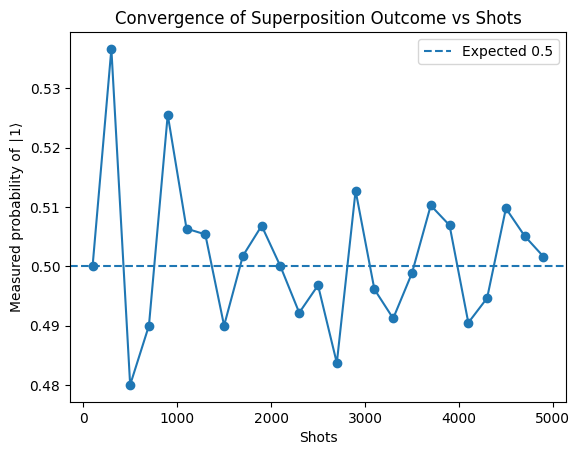

In [ ]:
# === Figure E.1.1a — Convergence of Superposition Outcome vs Shots ===

# Save and display

****Figure E.1.1a. Convergence of superposition outcome vs shots.****
  
As the number of measurement shots increases, the empirical probability p(∣1⟩) approaches the theoretical value 0.5 for state H∣0⟩. The curve plots p(∣1⟩) across increasing shots with a dashed 0.5 reference. Sampling variability diminishes roughly as 1/√N, demonstrating Born-rule convergence for a balanced superposition.

**Expected Results**

For the state |ψ⟩ = (|0⟩ + |1⟩)/√2, Born’s rule gives:

p(0) = |⟨0|ψ⟩|² = 0.5  
p(1) = |⟨1|ψ⟩|² = 0.5  

Finite-shot sampling introduces small variance that shrinks as 1/√N.

For small shot counts (e.g., 100), the measured proportion of ∣1⟩ may fluctuate noticeably due to statistical noise.

As the number of shots increases (e.g., up to 5000), the proportion should converge toward 0.5, reflecting the equal probability of ∣0⟩ and ∣1⟩ in the superposition state.

The plot will show a noisy curve that gradually stabilizes around 50%. A dashed horizontal line at 0.5 provides the ideal reference.

On real hardware, small deviations may persist due to readout errors and gate imperfections, but the overall convergence pattern remains visible.

**Technical Analysis (for the Visual)**

This experiment demonstrates two fundamental properties of quantum systems:

*Superposition:* The Hadamard gate transforms ∣0⟩ into (∣0⟩ + ∣1⟩)/√2, a balanced quantum state.

*Measurement statistics:* Unlike deterministic classical bits, quantum states reveal probabilities only through repeated trials. The variance decreases as the number of shots grows, illustrating the law of large numbers in quantum measurement.

In the context of quantum AI systems, this lab highlights how statistical estimation underpins more Beginner algorithms, such as variational quantum algorithms and expectation value estimation in quantum machine learning.

**Intuition Sidebar**

Think of the Hadamard gate as tossing a perfectly fair coin — heads and tails are equally likely. If you flip the coin only a few times, you might see 70% heads or 30% heads, just by chance. But as you flip thousands of times, the ratio settles closer to 50%. The qubit in superposition behaves the same way: each run is random, but the overall statistics reveal its true balance between ∣0⟩ and ∣1⟩.

**Paricipant Feedback**

Observe how the empirical probability p(∣1⟩) fluctuates for small shot counts and gradually stabilizes near 0.5 as more measurements are taken.
This behavior demonstrates statistical convergence toward the Born-rule prediction, showing that randomness averages into reliable probabilities through repeated sampling.


---

**Task 4 — Superposition Probability Distribution (H∣0⟩)**

The probabilistic nature of quantum measurement becomes apparent when a qubit in a balanced superposition is sampled repeatedly.

After applying the Hadamard gate to ∣0⟩, the qubit state becomes
∣ψ⟩ = (∣0⟩ + ∣1⟩)/√2, implying equal theoretical probabilities for both outcomes.
This figure visualizes the distribution of measured results as a histogram, translating abstract superposition amplitudes into observable frequency counts.


**Methodology Analysis**

* Circuit Preparation: Initialize a single-qubit circuit, apply H to generate the superposition ∣ψ⟩ = (∣0⟩ + ∣1⟩)/√2.

* Sampling: Perform a large number of measurements (e.g., 1000–5000 shots) to obtain counts of outcomes ‘0’ and ‘1’.

* Data Aggregation: Normalize counts to probabilities p(∣0⟩) and p(∣1⟩).

* Visualization: Plot a two-bar histogram to illustrate relative frequencies. Bars should be nearly equal in height, signifying a 50/50 distribution.
This procedure isolates the measurement layer of QAIS, demonstrating how quantum randomness produces stable statistical patterns over repeated trials.

**Challenge:** Write code that performs repeated measurements on a Hadamard-prepared qubit and plots the resulting distribution of ∣0⟩ and ∣1⟩ outcomes as normalized probabilities. This visualization should confirm the expected 50–50 distribution characteristic of a balanced quantum superposition.

Saved figure → Beginner_Labs/figures/P1_BeginLab01_E.1.1b.png


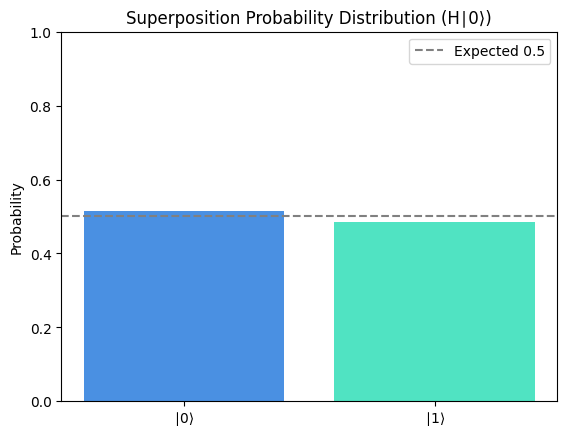

In [ ]:
# === Figure E.1.1b — Superposition Probability Distribution (H∣0⟩) ===


# Save and display


**Figure E.1.1b. Superposition Probability Distribution (H∣0⟩).**

A single-qubit superposition prepared by the Hadamard gate yields equiprobable outcomes in the computational basis. The histogram reports measured probabilities for ∣0⟩ and ∣1⟩ with a dashed 0.5 guideline. Small deviations reflect finite sampling and simulator noise; repeated runs concentrate near parity.

**Expected Results**

The ∣0⟩ and ∣1⟩ bars are approximately equal and straddle the 0.5 guideline, confirming a balanced superposition.

**Technical Analysis**

Imbalances are driven by finite sampling and device model noise. Increasing shots or repeating runs tightens confidence intervals and reduces disparity. The Hadamard rotates ∣0⟩ to the equator of the Bloch sphere, where computational-basis outcomes are equiprobable. Any residual skew stems from sampling noise, not circuit bias.

**Intuition Sidebar**

H∣0⟩ “splits” the qubit’s amplitude evenly ∣0⟩ and ∣1⟩. Measuring in the computational basis is like asking, “which way did the balance tip this time?”—and over many trials, both outcomes appear equally often.

**Technical Spotligh (analytic)**

Technical Spotlight (analytic).
H∣0⟩ = (∣0⟩ + ∣1⟩)/√2 ⇒ p(∣0⟩) = p(∣1⟩) = 0.5 exactly; deviations are statistical and noise-induced.

The pipeline demonstrates a complete measurement workflow: deterministic state → unitary that sets amplitudes (Hadamard) → sampling on a shot-based simulator → statistical estimation → Appendix-E-compliant artifact capture. The convergence plot validates sampling stability; the histogram validates the target distribution.

If your histogram diverges strongly from 0.5/0.5 with ≥ 5,000 shots, re-run the cell to eliminate transient noise.

**Participant Feedback**

Check that the histogram bars for ∣0⟩ and ∣1⟩ are nearly equal in height—each close to 0.5.
Small differences reflect finite sampling and simulator precision.
This confirms that the Hadamard gate correctly produces a balanced superposition, where both basis outcomes occur with equal probability.


---


**Conclusion — Superposition and Probability Distribution**

This lab establishes superposition as the first operational primitive of Quantum AI Systems (QAIS). By constructing and measuring a single-qubit circuit prepared with the Hadamard gate, participants directly observed how quantum amplitudes become measurable probabilities. The experiment confirmed that measured frequencies align with interference-defined probabilities rather than classical randomness. As the number of shots increased, observed frequencies converged toward the theoretical 50⁄50 split for H∣0⟩—demonstrating that quantum information is physical, quantifiable, and governed by coherent interference rather than chance. This validates the structured nature of quantum probability, where balance arises not from noise but from the geometry of interference itself.



**Key Take-Aways**

• H∣0⟩ ⇒ 50⁄50. A Hadamard on ∣0⟩ yields equal probabilities for ∣0⟩ and ∣1⟩.
• Sampling matters. Empirical estimates stabilize as shot count N increases (≈ 1⁄√N).
• Geometry → Probability. Equatorial states correspond to equal computational-basis outcomes.
• Foundation for later labs. Mastering superposition underpins entanglement, encoding, and variational learning across QAIS architectures.

**Congratulations**

You successfully built, simulated, and verified the first operational primitive of QAIS. Through this exercise, you established a calibrated workflow—from circuit preparation to measurement, visualization, and Appendix-E-compliant documentation—that forms the foundation for all subsequent labs on entanglement, encoding, and hybrid quantum optimization.

**Appendix E → Appendix B Cross-Reference**

For conceptual reinforcement of this laboratory, see **Appendix B — Quick Self-Check, Chapter 1 — Foundations of QAIS**:
- Review Questions 1–2 (quantum states and superposition/Born rule).
These items revisit the ½ : ½ probability interpretation validated in **E.1 Lab 1** (Figures E.1.1a–b).



---
📌 **How to save or submit your work**

- **If you are a student (graded/evaluated):**  
  1. Export your key plots or the entire notebook to PDF (File → Print/Save as PDF).  
  2. Save the notebook (`.ipynb`).  
  3. Bundle any extra files (CSVs/images) if used.  
  4. Upload to your LMS or repository as instructed (include your name and lab number).  
  5. Repro checklist: set a random seed where applicable, note backend and shots, and list package versions.  

- **If you are a professional/self‑learner (non‑graded exercise):**  
  1. Save the notebook (`File → Download .ipynb`) to your computer for personal reference.  
  2. Optionally export to PDF for archiving.  
  3. Keep any generated plots or data locally.  
  4. Use version control (GitHub, GitLab) if you wish to track your personal progress.


---

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17212825.svg)](https://doi.org/10.5281/zenodo.17212825)


**Official DOI:** [10.5281/zenodo.17212825](https://doi.org/10.5281/zenodo.17212825)  
**Companion Repository:** quscitech-labs  
**Publisher:** QuSciTech Press

DOI + © + QuSciTech